In [13]:
import requests, pandas as pd, matplotlib.pyplot as plt, math, time
from io import BytesIO
from PIL import Image

# API Practice

In [26]:
HEADERS = {"User-Agent": "DS-3001 Lab (student use) / requests"}
BASE = "https://pokeapi.co/api/v2"

In [27]:
names = ["ditto", "snorlax", "pikachu", "bulbasaur", "charmander"]
rows = []
for i, nm in enumerate(names):
    url = f"https://pokeapi.co/api/v2/pokemon/{nm}"
    r = requests.get(url, headers=HEADERS, timeout=20)
    r.raise_for_status()
    data = r.json()
    stats_dict = {s["stat"]["name"]: s["base_stat"] for s in data["stats"]}
    rows.append([i, url, None, stats_dict])

df = pd.DataFrame(rows, columns=["count", "url", "empty", "stats"])
display(df.head())

,count,url,empty,stats
0,0,https://pokeapi.co/api/v2/pokemon/ditto,None,"{'hp': 48, 'attack': 48, 'defense': 48, 'speci..."
1,1,https://pokeapi.co/api/v2/pokemon/snorlax,None,"{'hp': 160, 'attack': 110, 'defense': 65, 'spe..."
2,2,https://pokeapi.co/api/v2/pokemon/pikachu,None,"{'hp': 35, 'attack': 55, 'defense': 40, 'speci..."
3,3,https://pokeapi.co/api/v2/pokemon/bulbasaur,None,"{'hp': 45, 'attack': 49, 'defense': 49, 'speci..."
4,4,https://pokeapi.co/api/v2/pokemon/charmander,None,"{'hp': 39, 'attack': 52, 'defense': 43, 'speci..."


In [28]:
stats_expanded = df["stats"].apply(pd.Series)

In [29]:
stats_expanded

,hp,attack,defense,special-attack,special-defense,speed
0,48,48,48,48,48,48
1,160,110,65,65,110,30
2,35,55,40,50,50,90
3,45,49,49,65,65,45
4,39,52,43,60,50,65


In [30]:
details = []
for url in df["url"]:
    r = requests.get(url, headers=HEADERS, timeout=20)
    data = r.json()
    details.append({
        "name": data["name"],
        "id": data["id"],
        "base_experience": data["base_experience"],
        "height": data["height"],
        "weight": data["weight"],
        "types": ",".join([t["type"]["name"] for t in data["types"]]),
        "sprite_url": data["sprites"]["front_default"]
    })
    time.sleep(0.15)

In [31]:
df_details = pd.DataFrame(details)

In [33]:
df_details.head()

,name,id,base_experience,height,weight,types,sprite_url
0,ditto,132,101,3,40,normal,https://raw.githubusercontent.com/PokeAPI/spri...
1,snorlax,143,189,21,4600,normal,https://raw.githubusercontent.com/PokeAPI/spri...
2,pikachu,25,112,4,60,electric,https://raw.githubusercontent.com/PokeAPI/spri...
3,bulbasaur,1,64,7,69,"grass,poison",https://raw.githubusercontent.com/PokeAPI/spri...
4,charmander,4,62,6,85,fire,https://raw.githubusercontent.com/PokeAPI/spri...


In [34]:
df_final = pd.concat([df[["count","url"]], df_details, stats_expanded], axis=1)
df_final.head()

,count,url,name,id,base_experience,height,weight,types,sprite_url,hp,attack,defense,special-attack,special-defense,speed
0,0,https://pokeapi.co/api/v2/pokemon/ditto,ditto,132,101,3,40,normal,https://raw.githubusercontent.com/PokeAPI/spri...,48,48,48,48,48,48
1,1,https://pokeapi.co/api/v2/pokemon/snorlax,snorlax,143,189,21,4600,normal,https://raw.githubusercontent.com/PokeAPI/spri...,160,110,65,65,110,30
2,2,https://pokeapi.co/api/v2/pokemon/pikachu,pikachu,25,112,4,60,electric,https://raw.githubusercontent.com/PokeAPI/spri...,35,55,40,50,50,90
3,3,https://pokeapi.co/api/v2/pokemon/bulbasaur,bulbasaur,1,64,7,69,"grass,poison",https://raw.githubusercontent.com/PokeAPI/spri...,45,49,49,65,65,45
4,4,https://pokeapi.co/api/v2/pokemon/charmander,charmander,4,62,6,85,fire,https://raw.githubusercontent.com/PokeAPI/spri...,39,52,43,60,50,65


In [35]:
df_final.to_csv("pokemon_stats_expanded.csv", index=False)

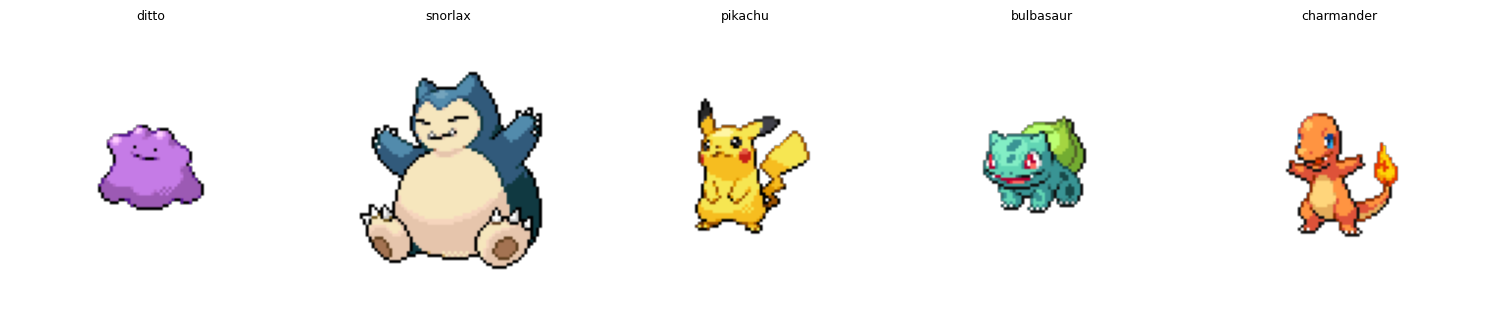

In [36]:
sprite_urls = df_final["sprite_url"].tolist()
labels = df_final["name"].tolist()

n = len(sprite_urls)
cols = 5
rows_needed = math.ceil(n / cols)
fig, axes = plt.subplots(rows_needed, cols, figsize=(15, 8))
axes = axes.flatten()

for i, ax in enumerate(axes):
    ax.axis("off")
    if i >= n or sprite_urls[i] is None:
        continue
    try:
        resp = requests.get(sprite_urls[i], headers=HEADERS, timeout=20)
        img = Image.open(BytesIO(resp.content)).convert("RGBA")
        ax.imshow(img)
        ax.set_title(labels[i], fontsize=9)
    except Exception:
        ax.text(0.5, 0.5, "error", ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.show()
